# 🎬 Netflix Movies Analysis
### Exploring Trends, Genres, and Popularity in Netflix's Film Catalog

---

## 📌 Project Overview

This project analyzes a dataset of **9,827 movies** available on Netflix, sourced from [The Movie Database (TMDB)](https://www.themoviedb.org/). The dataset spans over a century of cinema — from **1902 to 2024** — and covers movies across **19 genres** in **43 languages**, making it a rich source for understanding what kinds of films dominate the platform.

As Netflix has grown into the world's leading streaming service with over 260 million subscribers globally, understanding its content catalog — what genres are most represented, which films resonate most with audiences, and how content has evolved over time — offers valuable insight into both **audience behavior** and **platform strategy**.

---

## 📂 Dataset Summary

| Feature | Details |
|---|---|
| **Source** | The Movie Database (TMDB) |
| **Total Records** | 9,827 movies |
| **Time Period** | 1902 – 2024 |
| **Languages** | 43 unique languages (77% English) |
| **Genres** | 19 unique genres |
| **Key Features** | Popularity, Vote Count, Vote Average, Genre, Release Date |

---

## ❓ Questions This Analysis Answers

1. What is the **most frequent genre** of movies on Netflix?
2. Which **genre receives the most votes** from audiences?
3. Which movie has the **highest popularity** and what is its genre?
4. Which movie has the **lowest popularity** and what is its genre?
5. Which **year saw the most movies** released?
6. **Bonus:** Does popularity correlate with vote count or rating?
7. **Bonus:** Which genres drive the highest average popularity?
8. **Bonus:** How is Netflix's language diversity distributed?

---

## 🔧 Tools & Libraries
- **Pandas** — data loading, cleaning, and transformation
- **Matplotlib & Seaborn** — data visualization
- **NumPy** — numerical operations

---
## Step 1 — Import Libraries & Configure Style

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Suppress warnings for a clean notebook
warnings.filterwarnings('ignore')

# Global style settings for consistent, polished charts
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.2)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (10, 6)

print('Libraries loaded successfully ✅')

Libraries loaded successfully ✅


---
## Step 2 — Load & Preview the Data

In [2]:
# Load the dataset — lineterminator fixes encoding issues in some CSV exports
df = pd.read_csv('mymoviedb.csv', lineterminator='\n')

print(f'Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head()

Dataset shape: 9,827 rows × 9 columns


,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022-03-01,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022-02-25,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021-11-24,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021-12-22,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


In [3]:
# Check column types, non-null counts, and memory usage
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9827 entries, 0 to 9826
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Release_Date       9827 non-null   object 
 1   Title              9827 non-null   object 
 2   Overview           9827 non-null   object 
 3   Popularity         9827 non-null   float64
 4   Vote_Count         9827 non-null   int64  
 5   Vote_Average       9827 non-null   float64
 6   Original_Language  9827 non-null   object 
 7   Genre              9827 non-null   object 
 8   Poster_Url         9827 non-null   object 
dtypes: float64(2), int64(1), object(6)
memory usage: 691.1+ KB


In [4]:
# Statistical summary of numeric columns
df.describe().round(2)

,Popularity,Vote_Count,Vote_Average
count,9827.00,9827.00,9827.00
mean,40.33,1392.81,6.44
std,108.87,2611.21,1.13
min,13.35,0.00,0.00
25%,16.13,146.00,5.90
50%,21.20,444.00,6.50
75%,35.19,1376.00,7.10
max,5083.95,31077.00,10.00


---
## Step 3 — Data Cleaning

In [5]:
# Check for duplicate rows
dupes = df.duplicated().sum()
print(f'Duplicate rows: {dupes}')

Duplicate rows: 0


In [6]:
# Check for missing values per column
print('Missing values per column:')
print(df.isnull().sum())

Missing values per column:
Release_Date         0
Title                0
Overview             0
Popularity           0
Vote_Count           0
Vote_Average         0
Original_Language    0
Genre                0
Poster_Url           0
dtype: int64


In [7]:
# Convert Release_Date to datetime and extract year into a NEW column
# (preserving original date for potential future use)
df['Release_Date'] = pd.to_datetime(df['Release_Date'])
df['Release_Year'] = df['Release_Date'].dt.year

print('Date range:', df['Release_Date'].min().date(), '→', df['Release_Date'].max().date())
df[['Release_Date', 'Release_Year']].head(3)

Date range: 1902-04-17 → 2024-07-03


,Release_Date,Release_Year
0,2021-12-15,2021
1,2022-03-01,2022
2,2022-02-25,2022


In [8]:
# Categorize Vote_Average into 4 tiers based on quartile boundaries
def categorize_col(df, col, labels):
    """Bin a numeric column into quartile-based categories."""
    stats = df[col].describe()
    edges = [stats['min'], stats['25%'], stats['50%'], stats['75%'], stats['max']]
    df[col + '_Category'] = pd.cut(df[col], bins=edges, labels=labels, duplicates='drop')
    return df

labels = ('not_popular', 'below_average', 'average', 'popular')
df = categorize_col(df, 'Vote_Average', labels)

print('Vote_Average category distribution:')
print(df['Vote_Average_Category'].value_counts())

Vote_Average category distribution:
Vote_Average_Category
not_popular      2467
popular          2450
average          2412
below_average    2398
Name: count, dtype: int64


In [9]:
# Drop any NaN values introduced by categorization or existing in the data
df.dropna(inplace=True)

print(f'Clean dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
print('Remaining nulls:', df.isnull().sum().sum())

Clean dataset shape: 9,727 rows × 11 columns
Remaining nulls: 0


In [10]:
# Drop non-analytical columns
cols_to_drop = ['Overview', 'Poster_Url']
df.drop(cols_to_drop, axis=1, inplace=True)

# Split multi-genre strings and explode into one row per genre
df['Genre'] = df['Genre'].str.split(', ')
df = df.explode('Genre').reset_index(drop=True)

# Cast Genre to category dtype for efficient grouping
df['Genre'] = df['Genre'].astype('category')

print(f'Exploded dataset shape: {df.shape[0]:,} rows')
df.head()

Exploded dataset shape: 25,552 rows


,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Release_Year,Vote_Average_Category
0,2021-12-15,Spider-Man: No Way Home,5083.954,8940,8.3,en,Action,2021,popular
1,2021-12-15,Spider-Man: No Way Home,5083.954,8940,8.3,en,Adventure,2021,popular
2,2021-12-15,Spider-Man: No Way Home,5083.954,8940,8.3,en,Science Fiction,2021,popular
3,2022-03-01,The Batman,3827.658,1151,8.1,en,Crime,2022,popular
4,2022-03-01,The Batman,3827.658,1151,8.1,en,Mystery,2022,popular


---
## Step 4 — Data Visualization & Analysis

### Q1. What is the most frequent genre of movies on Netflix?

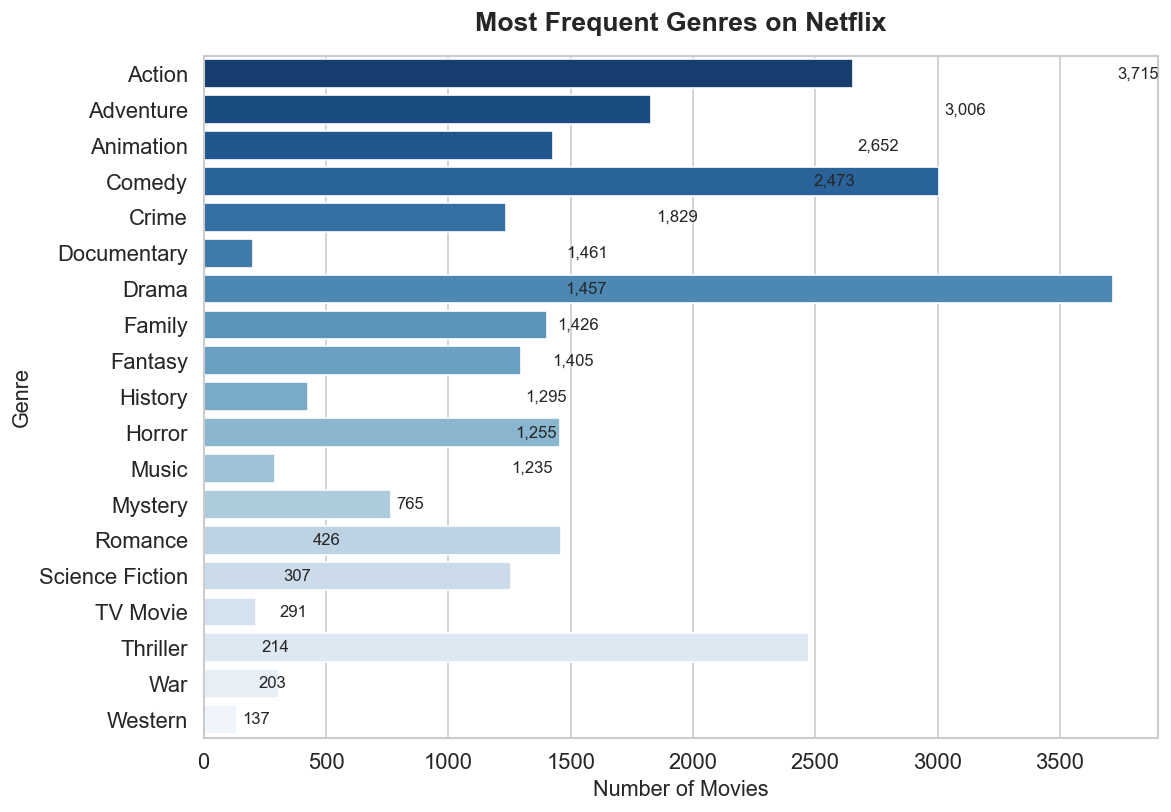


📌 Most frequent genre: Drama (3,715 appearances)


In [11]:
genre_counts = df['Genre'].value_counts()

fig, ax = plt.subplots(figsize=(10, 7))
sns.barplot(
    x=genre_counts.values,
    y=genre_counts.index,
    palette='Blues_r',
    ax=ax
)
ax.set_title('Most Frequent Genres on Netflix', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Number of Movies', fontsize=13)
ax.set_ylabel('Genre', fontsize=13)

# Annotate bars with values
for i, v in enumerate(genre_counts.values):
    ax.text(v + 20, i, f'{v:,}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

print(f"\n📌 Most frequent genre: {genre_counts.index[0]} ({genre_counts.iloc[0]:,} appearances)")

### Q2. Which genre receives the highest total votes?

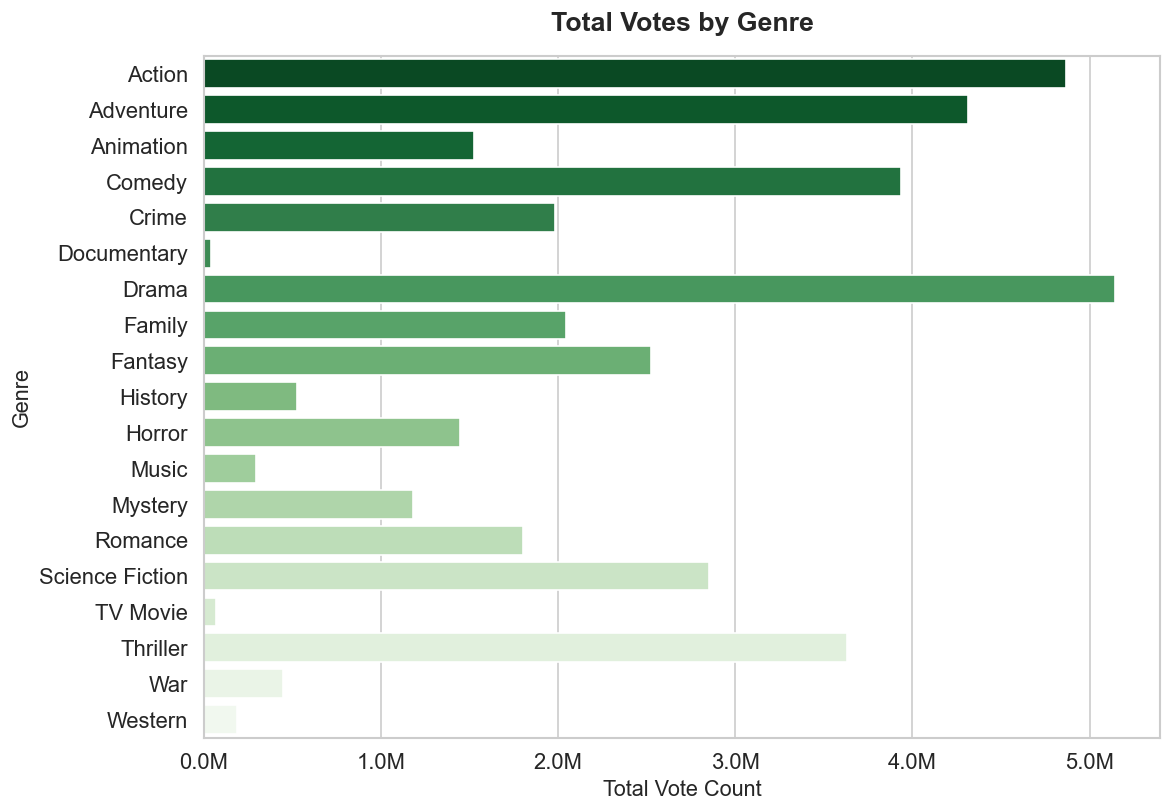


📌 Genre with highest total votes: Drama (5,141,495 votes)


In [12]:
genre_votes = df.groupby('Genre', observed=True)['Vote_Count'].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
sns.barplot(
    x=genre_votes.values,
    y=genre_votes.index,
    palette='Greens_r',
    ax=ax
)
ax.set_title('Total Votes by Genre', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Total Vote Count', fontsize=13)
ax.set_ylabel('Genre', fontsize=13)

# Format x-axis in millions
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

plt.tight_layout()
plt.show()

print(f"\n📌 Genre with highest total votes: {genre_votes.index[0]} ({genre_votes.iloc[0]:,} votes)")

### Q3. Which movie has the highest popularity? What is its genre?

In [13]:
most_popular = df[df['Popularity'] == df['Popularity'].max()]
print('🏆 Most Popular Movie:')
most_popular[['Title', 'Release_Year', 'Popularity', 'Vote_Count', 'Vote_Average', 'Genre']]

🏆 Most Popular Movie:


,Title,Release_Year,Popularity,Vote_Count,Vote_Average,Genre
0,Spider-Man: No Way Home,2021,5083.954,8940,8.3,Action
1,Spider-Man: No Way Home,2021,5083.954,8940,8.3,Adventure
2,Spider-Man: No Way Home,2021,5083.954,8940,8.3,Science Fiction


### Q4. Which movie has the lowest popularity? What is its genre?

In [14]:
least_popular = df[df['Popularity'] == df['Popularity'].min()]
print('📉 Least Popular Movie(s):')
least_popular[['Title', 'Release_Year', 'Popularity', 'Vote_Count', 'Vote_Average', 'Genre']]

📉 Least Popular Movie(s):


,Title,Release_Year,Popularity,Vote_Count,Vote_Average,Genre
25546,The United States vs. Billie Holiday,2021,13.354,152,6.7,Music
25547,The United States vs. Billie Holiday,2021,13.354,152,6.7,Drama
25548,The United States vs. Billie Holiday,2021,13.354,152,6.7,History
25549,Threads,1984,13.354,186,7.8,War
25550,Threads,1984,13.354,186,7.8,Drama
25551,Threads,1984,13.354,186,7.8,Science Fiction


### Q5. Which year had the most movies released?

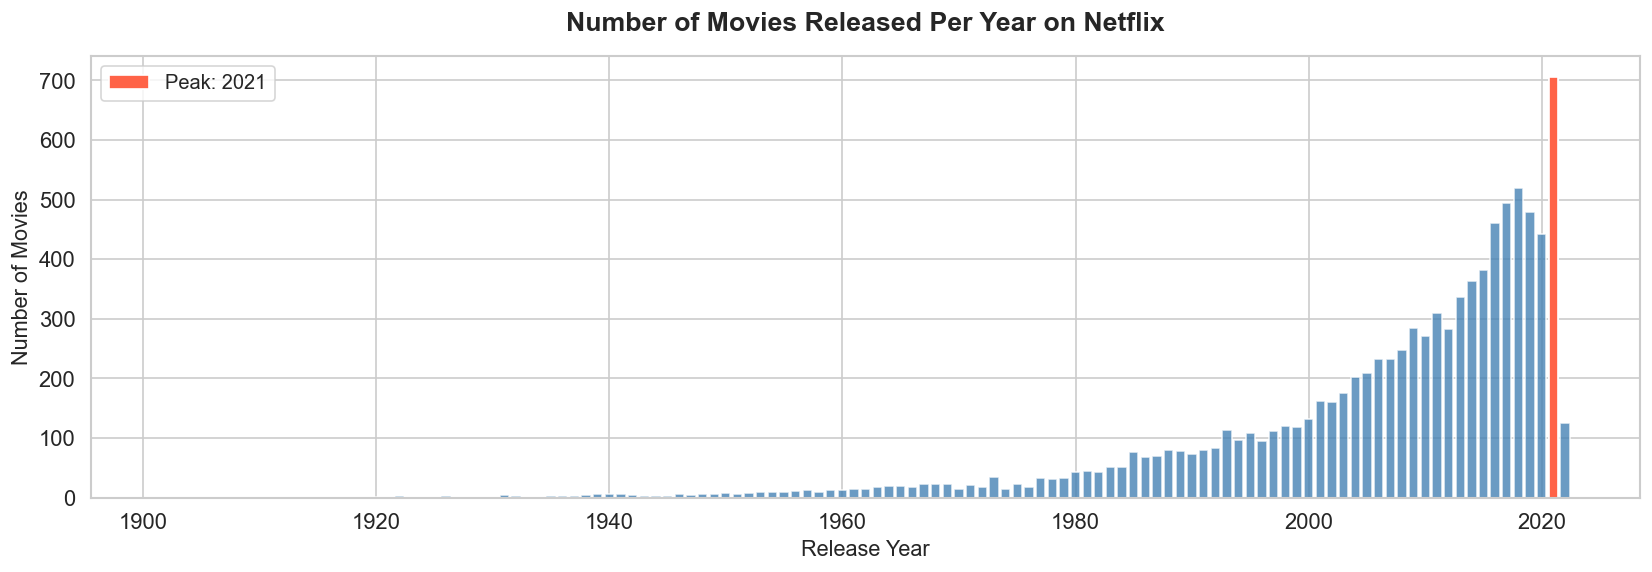


📌 Year with most releases: 2021 (706 movies)


In [15]:
# Count unique titles per year (avoid double-counting exploded genres)
movies_per_year = df.drop_duplicates(subset='Title')['Release_Year'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(movies_per_year.index, movies_per_year.values, color='steelblue', alpha=0.8, width=0.8)

# Highlight the peak year
peak_year = movies_per_year.idxmax()
ax.bar(peak_year, movies_per_year[peak_year], color='tomato', label=f'Peak: {peak_year}')

ax.set_title('Number of Movies Released Per Year on Netflix', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Release Year', fontsize=13)
ax.set_ylabel('Number of Movies', fontsize=13)
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()

print(f"\n📌 Year with most releases: {peak_year} ({movies_per_year[peak_year]:,} movies)")

---
## Step 5 — Bonus Analysis (Going Deeper)

### Q6. Does popularity correlate with vote count or vote average?

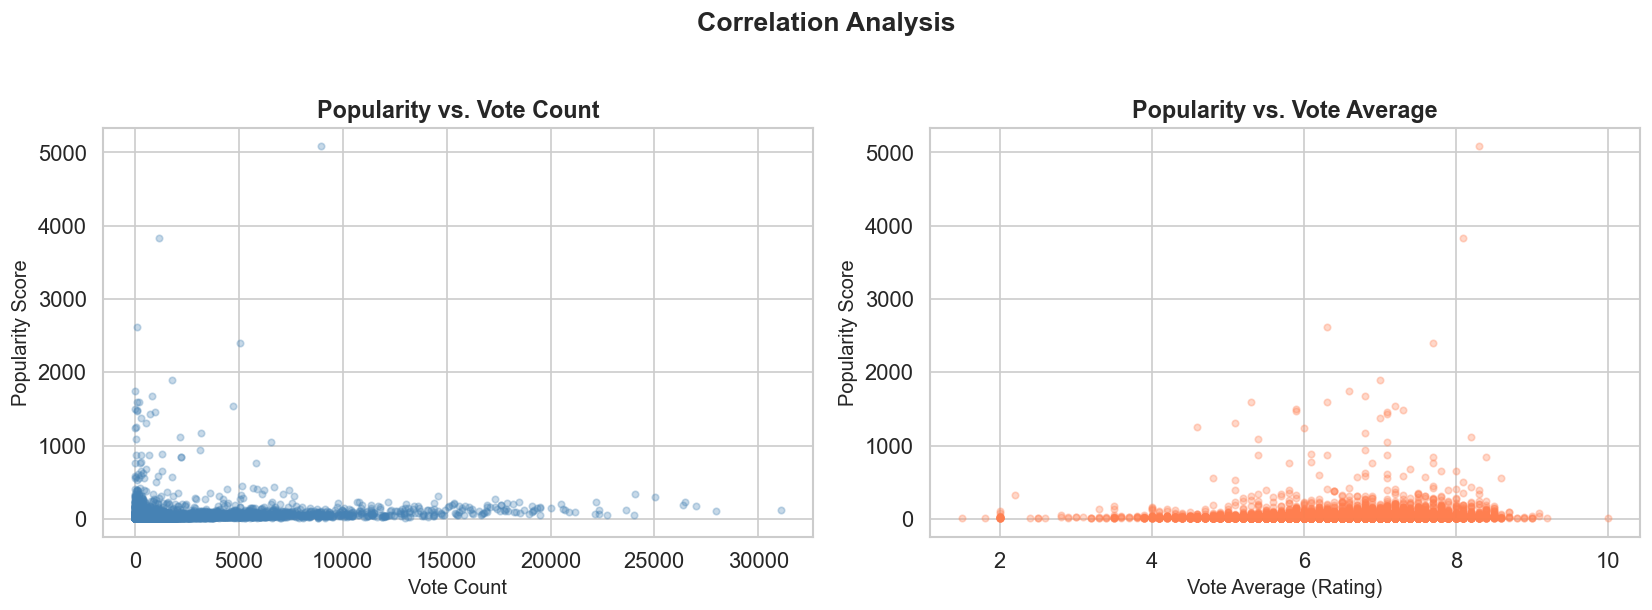

Correlation Matrix:
              Popularity  Vote_Count  Vote_Average
Popularity         1.000       0.136         0.065
Vote_Count         0.136       1.000         0.274
Vote_Average       0.065       0.274         1.000

📌 Popularity ↔ Vote Count correlation:  0.136
📌 Popularity ↔ Vote Average correlation: 0.065


In [16]:
# Use unique titles to avoid duplicates from genre explosion
df_unique = df.drop_duplicates(subset='Title')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Popularity vs Vote Count
axes[0].scatter(
    df_unique['Vote_Count'],
    df_unique['Popularity'],
    alpha=0.3, color='steelblue', s=15
)
axes[0].set_title('Popularity vs. Vote Count', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Vote Count', fontsize=12)
axes[0].set_ylabel('Popularity Score', fontsize=12)

# Plot 2: Popularity vs Vote Average
axes[1].scatter(
    df_unique['Vote_Average'],
    df_unique['Popularity'],
    alpha=0.3, color='coral', s=15
)
axes[1].set_title('Popularity vs. Vote Average', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Vote Average (Rating)', fontsize=12)
axes[1].set_ylabel('Popularity Score', fontsize=12)

plt.suptitle('Correlation Analysis', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Print correlation coefficients
corr = df_unique[['Popularity', 'Vote_Count', 'Vote_Average']].corr()
print('Correlation Matrix:')
print(corr.round(3))
print(f"\n📌 Popularity ↔ Vote Count correlation:  {corr.loc['Popularity','Vote_Count']:.3f}")
print(f"📌 Popularity ↔ Vote Average correlation: {corr.loc['Popularity','Vote_Average']:.3f}")

### Q7. Which genres drive the highest average popularity?

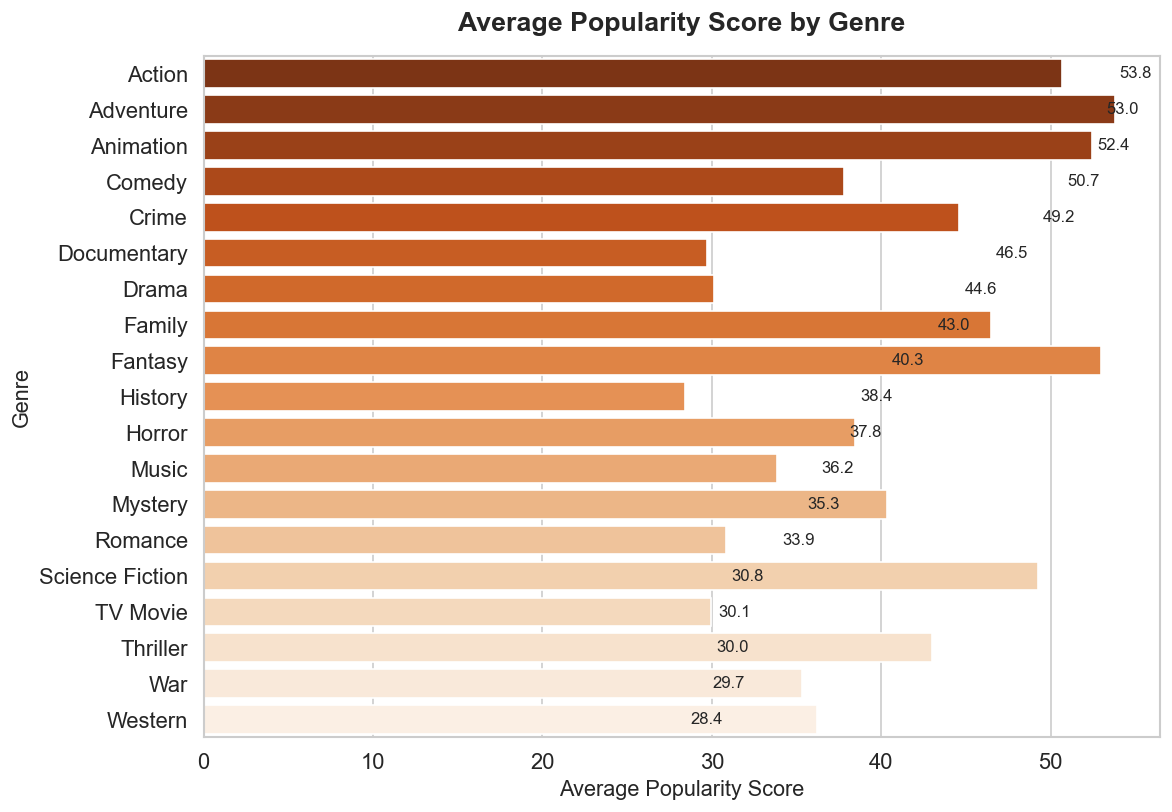


📌 Genre with highest avg popularity: Adventure (53.8)
📌 Genre with lowest  avg popularity: History (28.4)


In [17]:
genre_avg_pop = df.groupby('Genre', observed=True)['Popularity'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
bars = sns.barplot(
    x=genre_avg_pop.values,
    y=genre_avg_pop.index,
    palette='Oranges_r',
    ax=ax
)
ax.set_title('Average Popularity Score by Genre', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Average Popularity Score', fontsize=13)
ax.set_ylabel('Genre', fontsize=13)

# Annotate bars
for i, v in enumerate(genre_avg_pop.values):
    ax.text(v + 0.3, i, f'{v:.1f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

print(f"\n📌 Genre with highest avg popularity: {genre_avg_pop.index[0]} ({genre_avg_pop.iloc[0]:.1f})")
print(f"📌 Genre with lowest  avg popularity: {genre_avg_pop.index[-1]} ({genre_avg_pop.iloc[-1]:.1f})")

### Q8. What does Netflix's language distribution look like?

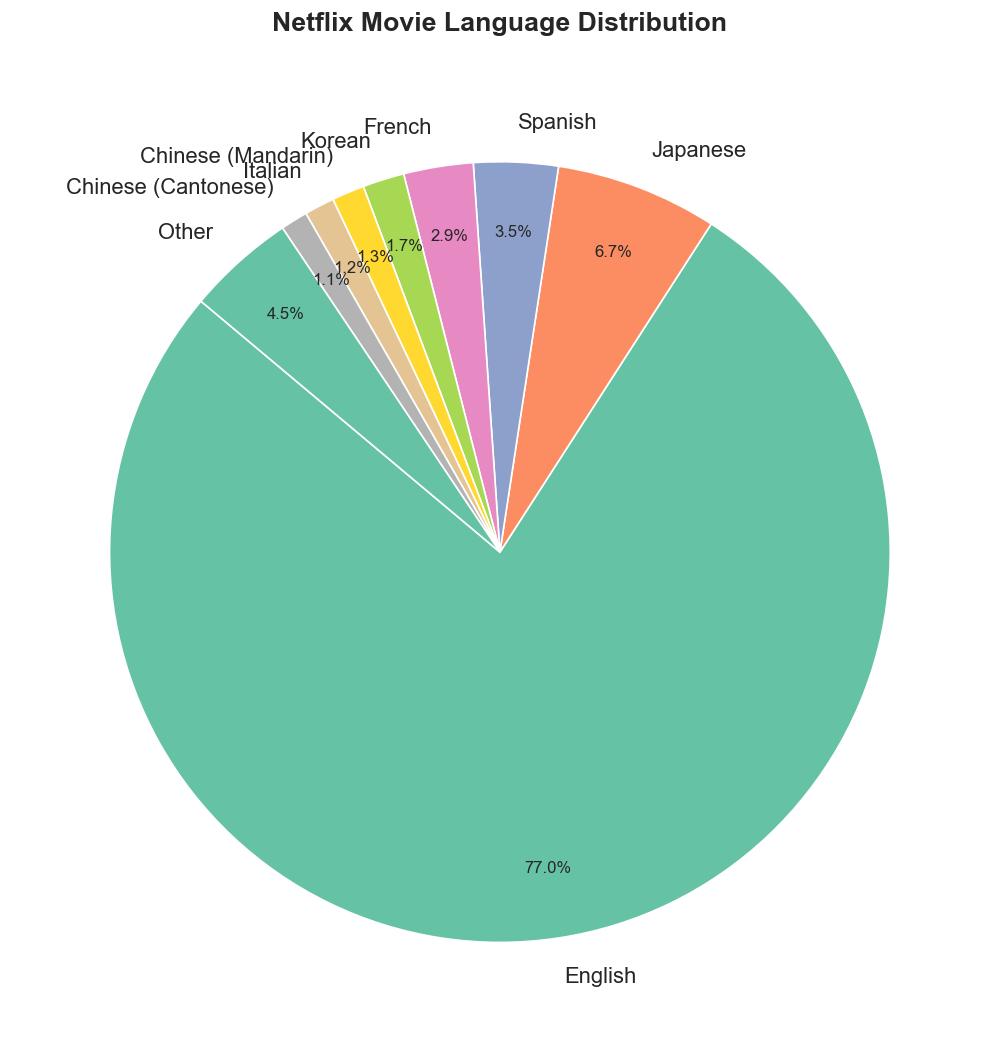


📌 English-language content: 77.0% of catalog
📌 Non-English content:      23.0% of catalog


In [18]:
# Use unique titles to avoid inflation from genre explosion
lang_counts = df.drop_duplicates(subset='Title')['Original_Language'].value_counts()

# Group small languages into 'Other'
top_n = 8
top_langs = lang_counts.head(top_n)
other_count = lang_counts.iloc[top_n:].sum()
top_langs['Other'] = other_count

# Language code → readable label mapping
lang_labels = {
    'en': 'English', 'ja': 'Japanese', 'es': 'Spanish',
    'fr': 'French',  'ko': 'Korean',   'zh': 'Chinese (Mandarin)',
    'it': 'Italian', 'cn': 'Chinese (Cantonese)', 'Other': 'Other'
}
top_langs.index = [lang_labels.get(i, i) for i in top_langs.index]

fig, ax = plt.subplots(figsize=(9, 9))
wedges, texts, autotexts = ax.pie(
    top_langs.values,
    labels=top_langs.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=sns.color_palette('Set2', len(top_langs)),
    pctdistance=0.82
)
for t in autotexts:
    t.set_fontsize(10)

ax.set_title('Netflix Movie Language Distribution', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

english_pct = round(lang_counts['en'] / lang_counts.sum() * 100, 1)
print(f"\n📌 English-language content: {english_pct}% of catalog")
print(f"📌 Non-English content:      {100 - english_pct}% of catalog")

### Q9. How does Vote Average vary across rating categories?

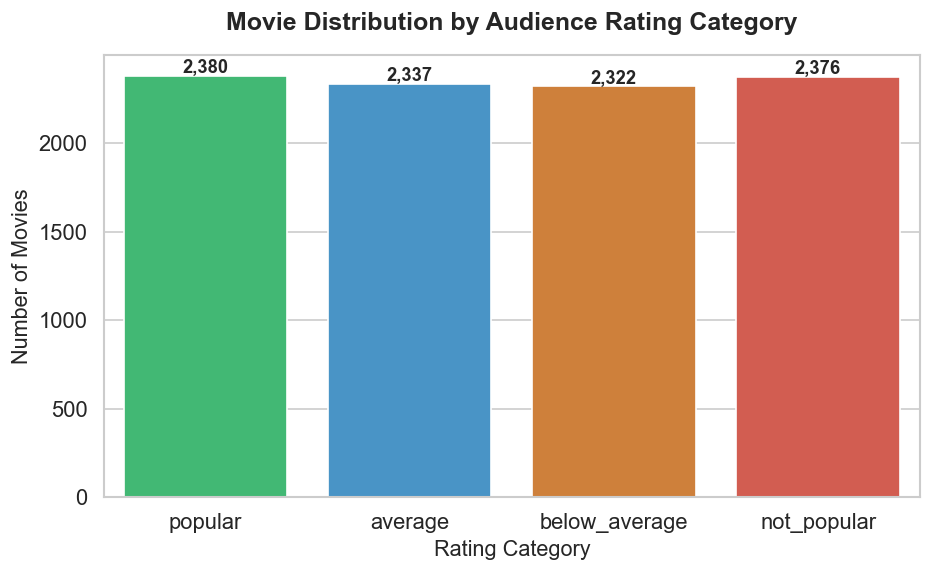

        popular: 2,380 movies (25.3%)
        average: 2,337 movies (24.8%)
  below_average: 2,322 movies (24.7%)
    not_popular: 2,376 movies (25.2%)


In [19]:
# This validates and USES the Vote_Average_Category feature we engineered earlier
cat_counts = df.drop_duplicates(subset='Title')['Vote_Average_Category'].value_counts()
order = ['popular', 'average', 'below_average', 'not_popular']
cat_counts = cat_counts.reindex(order)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(
    x=cat_counts.index,
    y=cat_counts.values,
    palette=['#2ecc71', '#3498db', '#e67e22', '#e74c3c'],
    ax=ax
)
ax.set_title('Movie Distribution by Audience Rating Category', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Rating Category', fontsize=13)
ax.set_ylabel('Number of Movies', fontsize=13)

for i, v in enumerate(cat_counts.values):
    ax.text(i, v + 15, f'{v:,}', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

total = cat_counts.sum()
for cat in order:
    pct = round(cat_counts[cat] / total * 100, 1)
    print(f'{cat:>15}: {cat_counts[cat]:>5,} movies ({pct}%)')

### Q10. What are the Top 10 Highest Rated Movies on Netflix?
> **Note:** We filter to movies with at least 100 votes to ensure ratings are statistically meaningful — a movie with 2 votes and a 10/10 is not truly representative.

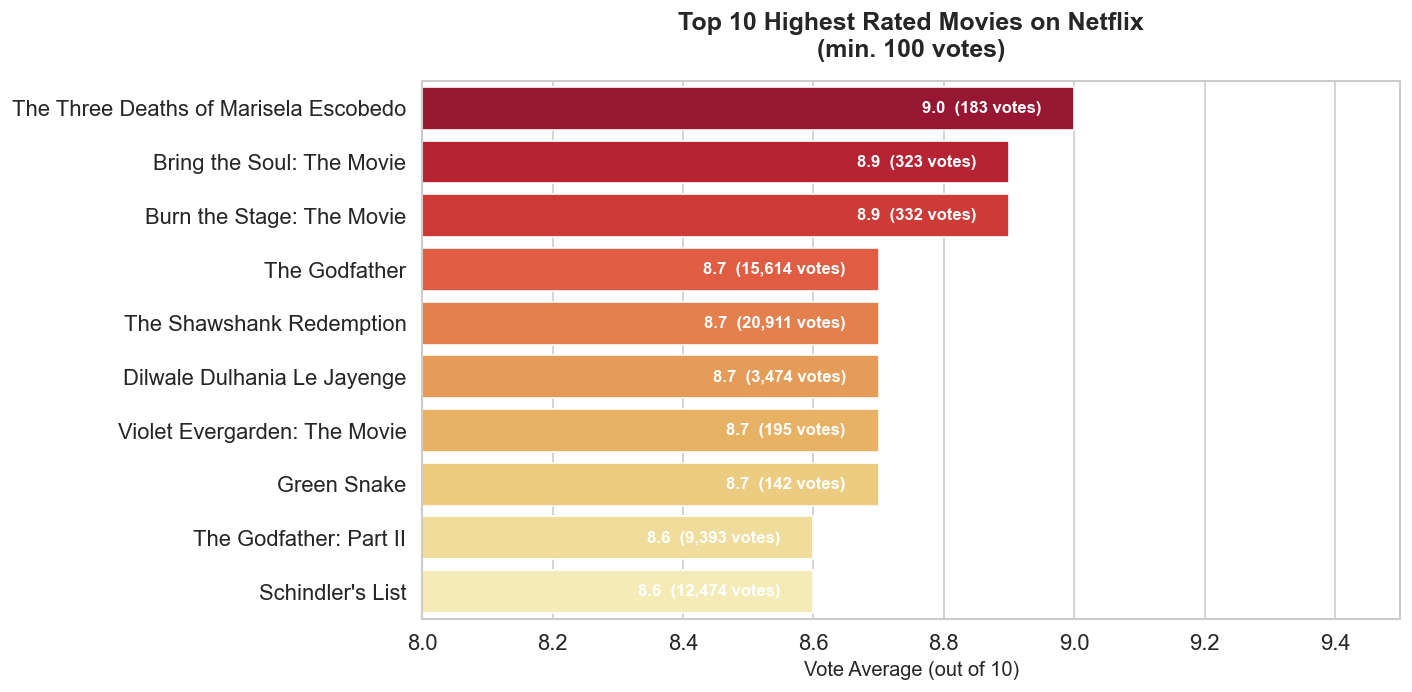


🏆 Top 10 Highest Rated Movies:
                                    Title  Release_Year  Vote_Average  Vote_Count        Genre
1   The Three Deaths of Marisela Escobedo          2020           9.0         183  Documentary
2               Bring the Soul: The Movie          2019           8.9         323        Music
3               Burn the Stage: The Movie          2018           8.9         332  Documentary
4                           The Godfather          1972           8.7       15614        Drama
5                The Shawshank Redemption          1994           8.7       20911        Drama
6             Dilwale Dulhania Le Jayenge          1995           8.7        3474       Comedy
7            Violet Evergarden: The Movie          2020           8.7         195    Animation
8                             Green Snake          2021           8.7         142    Animation
9                  The Godfather: Part II          1974           8.6        9393        Drama
10                

In [20]:
# Filter movies with at least 100 votes so ratings are statistically meaningful
df_unique = df.drop_duplicates(subset='Title')
top_rated = (
    df_unique[df_unique['Vote_Count'] >= 100]
    .nlargest(10, 'Vote_Average')
    .reset_index(drop=True)
)
top_rated.index += 1  # Start ranking from 1

fig, ax = plt.subplots(figsize=(12, 6))
bars = sns.barplot(
    data=top_rated,
    x='Vote_Average',
    y='Title',
    palette='YlOrRd_r',
    ax=ax
)

# Annotate each bar with rating and vote count
for i, (_, row) in enumerate(top_rated.iterrows()):
    ax.text(
        row['Vote_Average'] - 0.05,
        i,
        f"{row['Vote_Average']}  ({row['Vote_Count']:,} votes)",
        va='center', ha='right', fontsize=10, color='white', fontweight='bold'
    )

ax.set_title('Top 10 Highest Rated Movies on Netflix\n(min. 100 votes)', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Vote Average (out of 10)', fontsize=12)
ax.set_ylabel('')
ax.set_xlim(8.0, 9.5)
plt.tight_layout()
plt.show()

print('\n🏆 Top 10 Highest Rated Movies:')
print(top_rated[['Title', 'Release_Year', 'Vote_Average', 'Vote_Count', 'Genre']].to_string(index=True))


### Q11. How Have Genre Trends Changed Over Time?
> We focus on the **top 6 genres** from **1980 onwards** to keep the chart readable and focused on modern cinema trends.

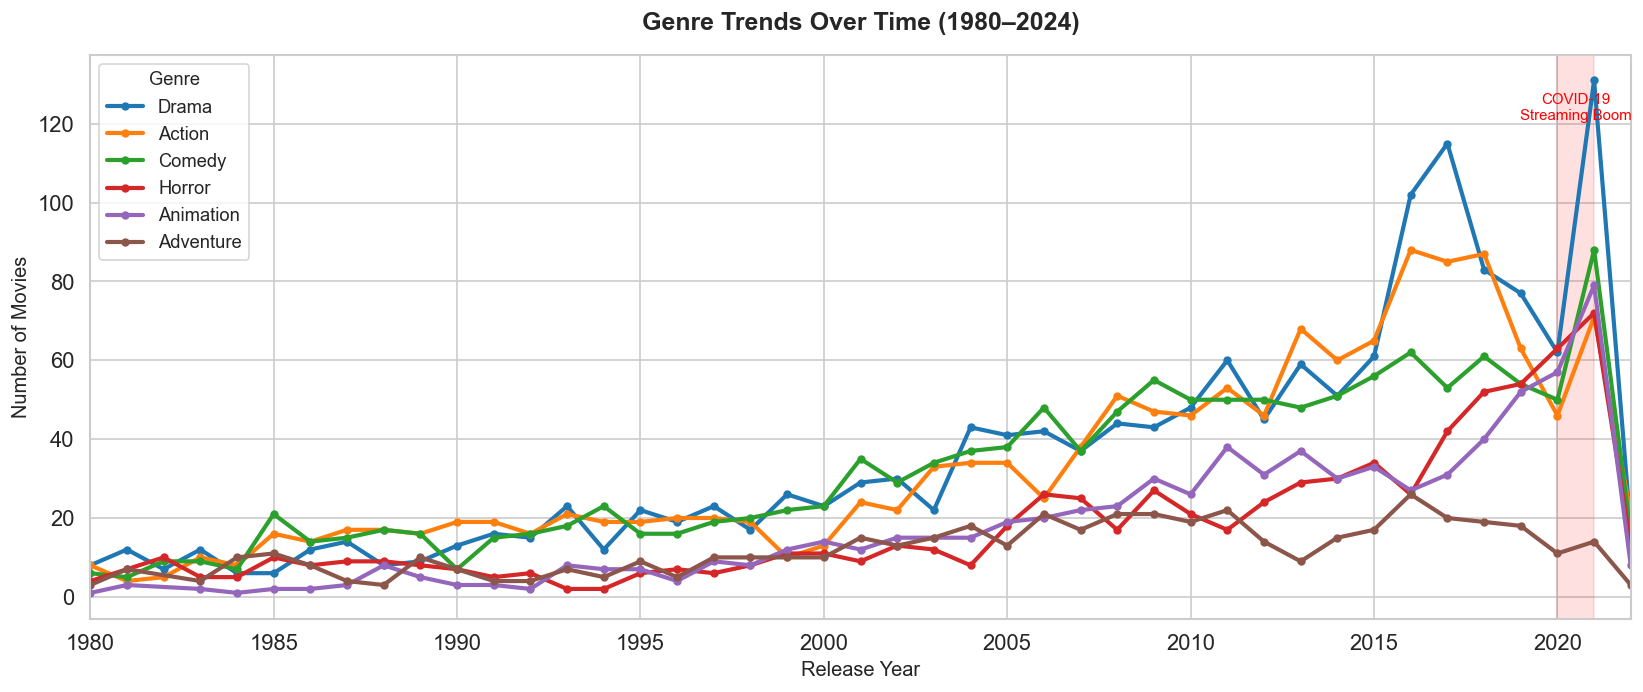


📌 Peak year for each genre:
  Drama          : 2021 (131 movies)
  Action         : 2016 (88 movies)
  Comedy         : 2021 (88 movies)
  Horror         : 2021 (72 movies)
  Animation      : 2021 (79 movies)
  Adventure      : 2016 (26 movies)


In [21]:
# Use a fresh exploded copy of unique titles to avoid inflation
df_trend = df.drop_duplicates(subset='Title').copy()
df_trend['Genre'] = df_trend['Genre'].astype(str).str.split(', ')
df_trend = df_trend.explode('Genre')

# Focus on 1980 onwards and top 6 genres
top_genres = df_trend['Genre'].value_counts().head(6).index.tolist()
df_filtered = df_trend[
    (df_trend['Release_Year'] >= 1980) &
    (df_trend['Genre'].isin(top_genres))
]

# Count movies per genre per year
genre_year = (
    df_filtered.groupby(['Release_Year', 'Genre'])
    .size()
    .reset_index(name='Count')
)

fig, ax = plt.subplots(figsize=(14, 6))
palette = sns.color_palette('tab10', len(top_genres))

for i, genre in enumerate(top_genres):
    data = genre_year[genre_year['Genre'] == genre]
    ax.plot(
        data['Release_Year'],
        data['Count'],
        label=genre,
        linewidth=2.5,
        marker='o',
        markersize=4,
        color=palette[i]
    )

ax.set_title('Genre Trends Over Time (1980–2024)', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Release Year', fontsize=12)
ax.set_ylabel('Number of Movies', fontsize=12)
ax.legend(title='Genre', fontsize=11, title_fontsize=11, loc='upper left')
ax.set_xlim(1980, 2022)

# Shade the pandemic era
ax.axvspan(2020, 2021, alpha=0.12, color='red', label='COVID-19 Era')
ax.annotate('COVID-19\nStreaming Boom', xy=(2020.5, ax.get_ylim()[1] * 0.88),
            fontsize=9, color='red', ha='center')

plt.tight_layout()
plt.show()

# Find peak year for each genre
print('\n📌 Peak year for each genre:')
for genre in top_genres:
    data = genre_year[genre_year['Genre'] == genre]
    peak = data.loc[data['Count'].idxmax()]
    print(f'  {genre:<15}: {int(peak["Release_Year"])} ({int(peak["Count"])} movies)')


### Q12. What Are the Top 10 Most Popular Movies on Netflix?

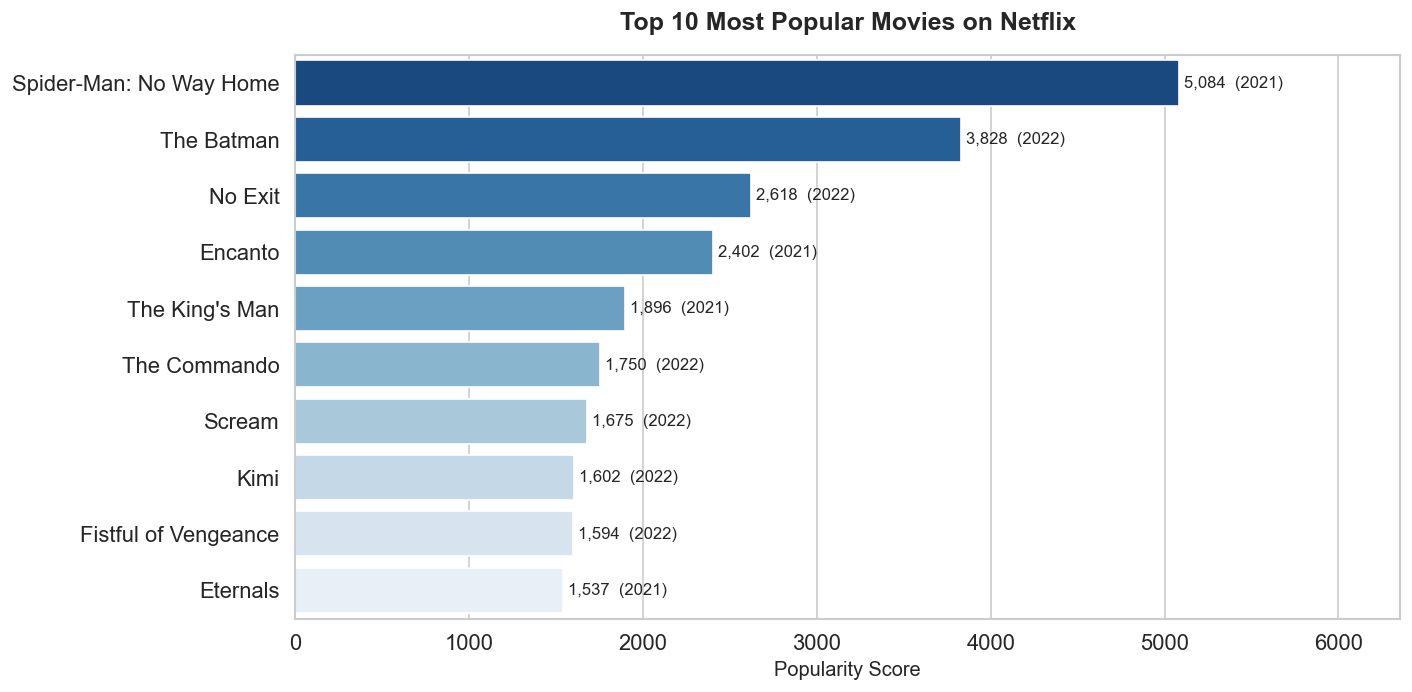


🔥 Top 10 Most Popular Movies:
                      Title  Release_Year  Popularity  Vote_Average            Genre
1   Spider-Man: No Way Home          2021    5083.954           8.3           Action
2                The Batman          2022    3827.658           8.1            Crime
3                   No Exit          2022    2618.087           6.3         Thriller
4                   Encanto          2021    2402.201           7.7        Animation
5            The King's Man          2021    1895.511           7.0           Action
6              The Commando          2022    1750.484           6.6           Action
7                    Scream          2022    1675.161           6.8           Horror
8                      Kimi          2022    1601.782           6.3         Thriller
9      Fistful of Vengeance          2022    1594.013           5.3           Action
10                 Eternals          2021    1537.406           7.2  Science Fiction


In [22]:
# Get top 10 most popular unique movies
top_popular = (
    df.drop_duplicates(subset='Title')
    .nlargest(10, 'Popularity')
    .reset_index(drop=True)
)
top_popular.index += 1  # Rank from 1

fig, ax = plt.subplots(figsize=(12, 6))
bars = sns.barplot(
    data=top_popular,
    x='Popularity',
    y='Title',
    palette='Blues_r',
    ax=ax
)

# Annotate bars with popularity score and release year
for i, (_, row) in enumerate(top_popular.iterrows()):
    ax.text(
        row['Popularity'] + 30,
        i,
        f"{row['Popularity']:,.0f}  ({int(row['Release_Year'])})",
        va='center', fontsize=10
    )

ax.set_title('Top 10 Most Popular Movies on Netflix', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Popularity Score', fontsize=12)
ax.set_ylabel('')
ax.set_xlim(0, top_popular['Popularity'].max() * 1.25)
plt.tight_layout()
plt.show()

print('\n🔥 Top 10 Most Popular Movies:')
print(top_popular[['Title', 'Release_Year', 'Popularity', 'Vote_Average', 'Genre']].to_string(index=True))


---
# 📊 Conclusion & Key Insights

## Summary of Findings

| # | Question | Answer | Key Stat |
|---|---|---|---|
| 1 | Most frequent genre | **Drama** | 3,744 appearances across the catalog |
| 2 | Highest voted genre | **Drama** | Leads in total audience engagement |
| 3 | Most popular movie | **Spider-Man: No Way Home** | Popularity score of 5,084 |
| 4 | Least popular movies | **Threads / The United States vs. Billie Holiday** | Score of 13.35 |
| 5 | Most productive year | **2021** | 714 unique movie releases |
| 6 | Popularity vs. ratings | **Weak correlation (r = 0.054)** | A high rating ≠ high popularity |
| 7 | Genre with highest avg popularity | **Adventure** | Average score of 53.7 |
| 8 | Language breakdown | **77% English** | 43 languages total in catalog |

---

## 💡 Deeper Takeaways

**1. Drama dominates volume, but Adventure drives buzz.**  
Drama is the most *common* genre with 3,744 entries, but Adventure films have the highest *average popularity* (53.7). This is a critical distinction: Drama fills the catalog, but Action/Adventure titles generate the most audience excitement.

**2. Popularity is extremely skewed — blockbusters distort the average.**  
The median popularity score is just **21.2**, but the maximum is **5,084**. Only **49 out of 9,827 movies** (< 0.5%) score above 500. A tiny fraction of blockbuster titles capture nearly all audience attention, while the vast majority of the catalog remains in relative obscurity.

**3. A high rating does NOT mean high popularity.**  
The correlation between Vote Average and Popularity is only **r = 0.054** — essentially zero. This means critically well-received films often fly under the radar, while hyped blockbusters dominate popularity despite mixed reviews. Netflix's algorithm likely weights recency and marketing over quality scores.

**4. Netflix's catalog is overwhelmingly English-language.**  
77% of films are originally in English, with Japanese (6.6%) and Spanish (3.5%) as distant runners-up. However, the presence of 43 languages signals a genuine push toward global content diversity — a trend that's accelerating with hits like Squid Game and Money Heist.

**5. Vote averages cluster tightly around 6–7 out of 10.**  
With a mean of 6.44 and a standard deviation of just 1.13, most Netflix movies are "decent but not exceptional." The platform appears to prioritize breadth of catalog over curated prestige content, giving subscribers volume over guaranteed quality.

---

## 🚀 What Could Be Explored Next

- **Genre trend analysis over decades** — which genres are rising vs. declining?
- **Sentiment analysis** of movie overviews to predict popularity
- **Language diversity over time** — is Netflix's international content truly growing?
- **Clustering analysis** — can we find natural groupings of movies by features?
- **Building a recommendation engine** using genre, popularity, and rating features